<a href="https://colab.research.google.com/github/essanchristian-maker/DI-Bootcamp/blob/master/Week7_Day1_Daily_challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Étape 1 : Installation de la bibliothèque nécessaire pour lire les fichiers .docx
!pip install python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 14.8 MB/s eta 0:00:00


In [2]:
import docx

# Étape 2 : Définir le chemin du fichier
file_path = '/content/Document sans titre (2).docx'

def read_docx(path):
    # Ouvrir le document
    doc = docx.Document(path)
    full_text = []

    # Parcourir chaque paragraphe du document
    for para in doc.paragraphs:
        full_text.append(para.text)

    # Joindre le texte avec des sauts de ligne
    return '\n'.join(full_text)

# Étape 3 : Extraire et afficher le contenu
try:
    content = read_docx(file_path)
    print("--- Contenu du document ---\n")
    print(content)
except Exception as e:
    print(f"Une erreur est survenue lors de la lecture : {e}")

--- Contenu du document ---

Daily Challenge : Text Analysis of books using word cloud
👩‍🏫 👩🏿‍🏫 What You’ll learn
Text preprocessing
Text Analysis
Bag of words (BoW) method
TF-IDF
Important
Create a virtual enviroment to the NLP course and work always on it.

Text preprocessing
For this exercises we will be using NLTK and spaCy
The corpus will be the Lewis Carrol books:
Alice’s Adventures in Wonderland
THROUGH THE LOOKING-GLASS And What Alice Found There
A Tangled Tale
1. Using requests to access the contents online, create a function load_texts().This function should recive a list of urls, load them, clean non-words using regular expressions and append the cleaned text to the corpus that will be returned.
2. Print the first 200 characteres of each text.
Are there parts of the text that are not relevant to the analysis? If so, you need to remove them.
hint: You can use slicing to start and stop the text where you need (ignoring autoral credits in the begining and end) looking for the f

In [3]:
import requests
import re

# URLs des livres de Lewis Carroll (Projet Gutenberg)
urls = [
    'https://www.gutenberg.org/files/11/11-0.txt',  # Alice’s Adventures in Wonderland
    'https://www.gutenberg.org/files/12/12-0.txt',  # Through the Looking-Glass
    'https://www.gutenberg.org/cache/epub/29042/pg29042.txt' # A Tangled Tale
]

def load_texts(url_list):
    corpus = []
    for url in url_list:
        # 1. Téléchargement du texte
        response = requests.get(url)
        text = response.text

        # 2. Nettoyage : on ne garde que les mots (lettres) et les espaces
        # re.sub remplace tout ce qui n'est pas une lettre par un espace
        cleaned_text = re.sub(r'[^a-zA-Z\s]', '', text)

        corpus.append(cleaned_text)
    return corpus

# Exécution de la fonction
books_corpus = load_texts(urls)

# Affichage des 200 premiers caractères pour vérification
titles = ["Alice's Adventures in Wonderland", "Through the Looking-Glass", "A Tangled Tale"]
for i, text in enumerate(books_corpus):
    print(f"--- {titles[i]} ---")
    print(text[:200] + "...\n")

--- Alice's Adventures in Wonderland ---
 START OF THE PROJECT GUTENBERG EBOOK  

Illustration




Alices Adventures in Wonderland

by Lewis Carroll

THE MILLENNIUM FULCRUM EDITION 

Contents

 CHAPTER I     Down the RabbitHole
 CHAPTER II  ...

--- Through the Looking-Glass ---
 START OF THE PROJECT GUTENBERG EBOOK  

Illustration




THROUGH THE LOOKINGGLASS

And What Alice Found There

By Lewis Carroll

The Millennium Fulcrum Edition 




DRAMATIS PERSON
As arranged before...

--- A Tangled Tale ---
The Project Gutenberg eBook of A Tangled Tale
    
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
wh...



In [5]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

# Étape 2 : Nettoyage des parties non pertinentes (Slicing)
def clean_gutenberg_metadata(text):
    # On cherche approximativement le début et la fin de l'histoire
    # Note: Dans un cas réel, on chercherait les marqueurs 'START' et 'END'
    start_idx = text.find('START') if text.find('START') != -1 else 0
    end_idx = text.find('END') if text.find('END') != -1 else len(text)
    return text[start_idx:end_idx]

# Application du nettoyage
cleaned_corpus = [clean_gutenberg_metadata(t) for t in books_corpus]

# Étape 3 : Tokenisation
book_tokens = []
for i, text in enumerate(cleaned_corpus):
    tokens = word_tokenize(text)
    book_tokens.append(tokens)
    print(f"--- Tokens pour {titles[i]} (150 premiers) ---")
    print(tokens[:150])
    print('\n')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


--- Tokens pour Alice's Adventures in Wonderland (150 premiers) ---
['START', 'OF', 'THE', 'PROJECT', 'GUTENBERG', 'EBOOK', 'Illustration', 'Alices', 'Adventures', 'in', 'Wonderland', 'by', 'Lewis', 'Carroll', 'THE', 'MILLENNIUM', 'FULCRUM', 'EDITION', 'Contents', 'CHAPTER', 'I', 'Down', 'the', 'RabbitHole', 'CHAPTER', 'II', 'The', 'Pool', 'of', 'Tears', 'CHAPTER', 'III', 'A', 'CaucusRace', 'and', 'a', 'Long', 'Tale', 'CHAPTER', 'IV', 'The', 'Rabbit', 'Sends', 'in', 'a', 'Little', 'Bill', 'CHAPTER', 'V', 'Advice', 'from', 'a', 'Caterpillar', 'CHAPTER', 'VI', 'Pig', 'and', 'Pepper', 'CHAPTER', 'VII', 'A', 'Mad', 'TeaParty', 'CHAPTER', 'VIII', 'The', 'Queens', 'CroquetGround', 'CHAPTER', 'IX', 'The', 'Mock', 'Turtles', 'Story', 'CHAPTER', 'X', 'The', 'Lobster', 'Quadrille', 'CHAPTER', 'XI', 'Who', 'Stole', 'the', 'Tarts', 'CHAPTER', 'XII', 'Alices', 'Evidence', 'CHAPTER', 'I', 'Down', 'the', 'RabbitHole', 'Alice', 'was', 'beginning', 'to', 'get', 'very', 'tired', 'of', 'sitting', 'by', '

In [6]:
from nltk.corpus import stopwords
nltk.download('stopwords')

# Liste des mots vides en anglais
stop_words = set(stopwords.words('english'))

book_tokens_filtered = []

for i, tokens in enumerate(book_tokens):
    # Filtrer les tokens : on garde ceux qui ne sont pas dans la liste des stopwords
    filtered = [w for w in tokens if not w.lower() in stop_words]
    book_tokens_filtered.append(filtered)

    print(f"--- {titles[i]} ---")
    print(f"Nombre de tokens original : {len(tokens)}")
    print(f"Nombre de tokens après filtrage : {len(filtered)}")
    print(f"Exemple des 20 premiers tokens filtrés : {filtered[:20]}\n")

--- Alice's Adventures in Wonderland ---
Nombre de tokens original : 26470
Nombre de tokens après filtrage : 12683
Exemple des 20 premiers tokens filtrés : ['START', 'PROJECT', 'GUTENBERG', 'EBOOK', 'Illustration', 'Alices', 'Adventures', 'Wonderland', 'Lewis', 'Carroll', 'MILLENNIUM', 'FULCRUM', 'EDITION', 'Contents', 'CHAPTER', 'RabbitHole', 'CHAPTER', 'II', 'Pool', 'Tears']

--- Through the Looking-Glass ---
Nombre de tokens original : 29611
Nombre de tokens après filtrage : 14641
Exemple des 20 premiers tokens filtrés : ['START', 'PROJECT', 'GUTENBERG', 'EBOOK', 'Illustration', 'LOOKINGGLASS', 'Alice', 'Found', 'Lewis', 'Carroll', 'Millennium', 'Fulcrum', 'Edition', 'DRAMATIS', 'PERSON', 'arranged', 'commencement', 'game', 'WHITE', 'RED']

--- A Tangled Tale ---
Nombre de tokens original : 12242
Nombre de tokens après filtrage : 6372
Exemple des 20 premiers tokens filtrés : ['START', 'PROJECT', 'GUTENBERG', 'EBOOK', 'TANGLED', 'TALE', 'Produced', 'Chris', 'Curnow', 'Carla', 'Foust'

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [7]:
from nltk.stem import PorterStemmer

# Initialisation du PorterStemmer
stemmer = PorterStemmer()

book_tokens_stemmed = []

for i, tokens in enumerate(book_tokens_filtered):
    # Application du stemming sur chaque mot filtré
    stemmed = [stemmer.stem(w) for w in tokens]
    book_tokens_stemmed.append(stemmed)

    print(f"--- {titles[i]} (50 premiers stems) ---")
    print(stemmed[:50])
    print('\n')


--- Alice's Adventures in Wonderland (50 premiers stems) ---
['start', 'project', 'gutenberg', 'ebook', 'illustr', 'alic', 'adventur', 'wonderland', 'lewi', 'carrol', 'millennium', 'fulcrum', 'edit', 'content', 'chapter', 'rabbithol', 'chapter', 'ii', 'pool', 'tear', 'chapter', 'iii', 'caucusrac', 'long', 'tale', 'chapter', 'iv', 'rabbit', 'send', 'littl', 'bill', 'chapter', 'v', 'advic', 'caterpillar', 'chapter', 'vi', 'pig', 'pepper', 'chapter', 'vii', 'mad', 'teaparti', 'chapter', 'viii', 'queen', 'croquetground', 'chapter', 'ix', 'mock']


--- Through the Looking-Glass (50 premiers stems) ---
['start', 'project', 'gutenberg', 'ebook', 'illustr', 'lookingglass', 'alic', 'found', 'lewi', 'carrol', 'millennium', 'fulcrum', 'edit', 'dramati', 'person', 'arrang', 'commenc', 'game', 'white', 'red', 'piec', 'pawn', 'pawn', 'piec', 'tweedlede', 'daisi', 'daisi', 'humpti', 'dumpti', 'unicorn', 'haigha', 'messeng', 'carpent', 'sheep', 'oyster', 'oyster', 'walru', 'w', 'queen', 'lili', 'tiger

In [8]:
import spacy

# Chargement du modèle linguistique anglais de spaCy
# On désactive le 'parser' et le 'ner' pour accélérer le traitement car on ne veut que les lemmes ici
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

book_tokens_lemmatized = []

for i, original_text in enumerate(cleaned_corpus):
    # spaCy traite le texte brut pour comprendre le contexte
    # Nous limitons à un échantillon si le texte est trop long,
    # mais ici nous allons traiter les 5000 premiers mots pour l'exemple
    doc = nlp(" ".join(book_tokens_filtered[i][:1000]))

    lemmes = [token.lemma_ for token in doc]
    book_tokens_lemmatized.append(lemmes)

    print(f"--- {titles[i]} (50 premiers lemmes) ---")
    print(lemmes[:50])
    print('\n')


--- Alice's Adventures in Wonderland (50 premiers lemmes) ---
['START', 'PROJECT', 'GUTENBERG', 'EBOOK', 'Illustration', 'Alices', 'Adventures', 'Wonderland', 'Lewis', 'Carroll', 'MILLENNIUM', 'FULCRUM', 'EDITION', 'content', 'CHAPTER', 'RabbitHole', 'CHAPTER', 'II', 'Pool', 'Tears', 'CHAPTER', 'III', 'CaucusRace', 'Long', 'Tale', 'chapter', 'IV', 'rabbit', 'send', 'little', 'Bill', 'chapter', 'V', 'Advice', 'Caterpillar', 'CHAPTER', 'VI', 'Pig', 'Pepper', 'chapter', 'VII', 'Mad', 'TeaParty', 'CHAPTER', 'VIII', 'Queens', 'CroquetGround', 'chapter', 'IX', 'Mock']


--- Through the Looking-Glass (50 premiers lemmes) ---
['START', 'PROJECT', 'GUTENBERG', 'EBOOK', 'Illustration', 'LOOKINGGLASS', 'Alice', 'find', 'Lewis', 'Carroll', 'Millennium', 'Fulcrum', 'Edition', 'DRAMATIS', 'person', 'arrange', 'commencement', 'game', 'WHITE', 'RED', 'piece', 'pawns', 'pawns', 'PIECES', 'Tweedledee', 'Daisy', 'Daisy', 'Humpty', 'Dumpty', 'Unicorn', 'Haigha', 'Messenger', 'Carpenter', 'Sheep', 'Oyster'

In [9]:
import nltk
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

# Étape 8 : Identifier les POS Tags (Part-of-Speech)
book_pos_tags = []

for i, tokens in enumerate(book_tokens_filtered):
    # On utilise un échantillon des 100 premiers mots pour l'affichage
    tags = nltk.pos_tag(tokens[:100])
    book_pos_tags.append(tags)

    print(f"--- POS Tags pour {titles[i]} (20 premiers) ---")
    print(tags[:20])
    print('\n')

# Note pour l'étape 7 :
# Le Stemming est plus rapide mais moins précis (mots tronqués).
# La Lemmatisation est plus précise car elle ramène au dictionnaire.

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


--- POS Tags pour Alice's Adventures in Wonderland (20 premiers) ---
[('START', 'NNP'), ('PROJECT', 'NNP'), ('GUTENBERG', 'NNP'), ('EBOOK', 'NNP'), ('Illustration', 'NNP'), ('Alices', 'NNP'), ('Adventures', 'NNP'), ('Wonderland', 'NNP'), ('Lewis', 'NNP'), ('Carroll', 'NNP'), ('MILLENNIUM', 'NNP'), ('FULCRUM', 'NNP'), ('EDITION', 'NNP'), ('Contents', 'NNP'), ('CHAPTER', 'NNP'), ('RabbitHole', 'NNP'), ('CHAPTER', 'NNP'), ('II', 'NNP'), ('Pool', 'NNP'), ('Tears', 'NNP')]


--- POS Tags pour Through the Looking-Glass (20 premiers) ---
[('START', 'NNP'), ('PROJECT', 'NNP'), ('GUTENBERG', 'NNP'), ('EBOOK', 'NNP'), ('Illustration', 'NNP'), ('LOOKINGGLASS', 'NNP'), ('Alice', 'NNP'), ('Found', 'NNP'), ('Lewis', 'NNP'), ('Carroll', 'NNP'), ('Millennium', 'NNP'), ('Fulcrum', 'NNP'), ('Edition', 'NNP'), ('DRAMATIS', 'NNP'), ('PERSON', 'NNP'), ('arranged', 'VBD'), ('commencement', 'JJ'), ('game', 'NN'), ('WHITE', 'NNP'), ('RED', 'NNP')]


--- POS Tags pour A Tangled Tale (20 premiers) ---
[('START'

In [12]:
import nltk
nltk.download('maxent_ne_chunker')
nltk.download('maxent_ne_chunker_tab')
nltk.download('words')

# Étape 9 : Identifier les entités (NER)
print("--- Analyse des Entités (NER) ---\n")
for i, tags in enumerate(book_pos_tags):
    # On utilise les tags générés précédemment pour trouver les entités
    tree = nltk.ne_chunk(tags)
    entities = []
    for leaf in tree:
        if hasattr(leaf, 'label'):
            entities.append(f"{' '.join(c[0] for c in leaf)} ({leaf.label()})")

    print(f"{titles[i]} (10 premières entités détectées) :")
    print(entities[:10])
    print('\n')


[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker_tab.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!


--- Analyse des Entités (NER) ---

Alice's Adventures in Wonderland (10 premières entités détectées) :
['Lewis Carroll (PERSON)', 'RabbitHole (ORGANIZATION)', 'Rabbit Sends Little (PERSON)', 'Bill (PERSON)', 'Pepper (PERSON)', 'Turtles Story (PERSON)', 'RabbitHole (ORGANIZATION)']


Through the Looking-Glass (10 premières entités détectées) :
['LOOKINGGLASS (ORGANIZATION)', 'Lewis Carroll Millennium Fulcrum Edition (PERSON)', 'DRAMATIS (ORGANIZATION)', 'WHITE (ORGANIZATION)', 'Dumpty Unicorn Haigha Messenger Carpenter Sheep Oyster Oyster Walrus (PERSON)', 'Tigerlily R Queen (PERSON)', 'Oyster Oyster Crow (PERSON)', 'Hatta Frog (PERSON)', 'WHITE (ORGANIZATION)', 'White Pawn (FACILITY)']


A Tangled Tale (10 premières entités détectées) :
['Chris Curnow Carla Foust Lindy Walsh Online Distributed (PERSON)', 'Music (PERSON)', 'Linda Cantoni (PERSON)', 'Minor (PERSON)', 'TANGLED (ORGANIZATION)', 'SECOND (ORGANIZATION)', 'MACMILLAN (ORGANIZATION)', 'RICHARD (ORGANIZATION)', 'Suffolk Pupil Be

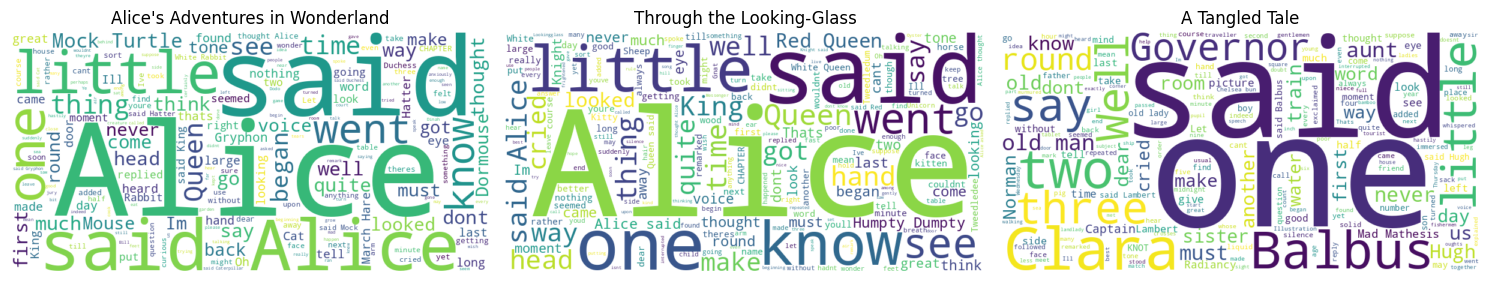

In [11]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Analyse - Étape 1 : Génération des Word Clouds
plt.figure(figsize=(15, 10))

for i, tokens in enumerate(book_tokens_filtered):
    # Joindre les tokens filtrés en une seule chaîne de caractères
    text_for_cloud = " ".join(tokens)

    # Création du nuage de mots
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_for_cloud)

    # Affichage
    plt.subplot(1, 3, i+1)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

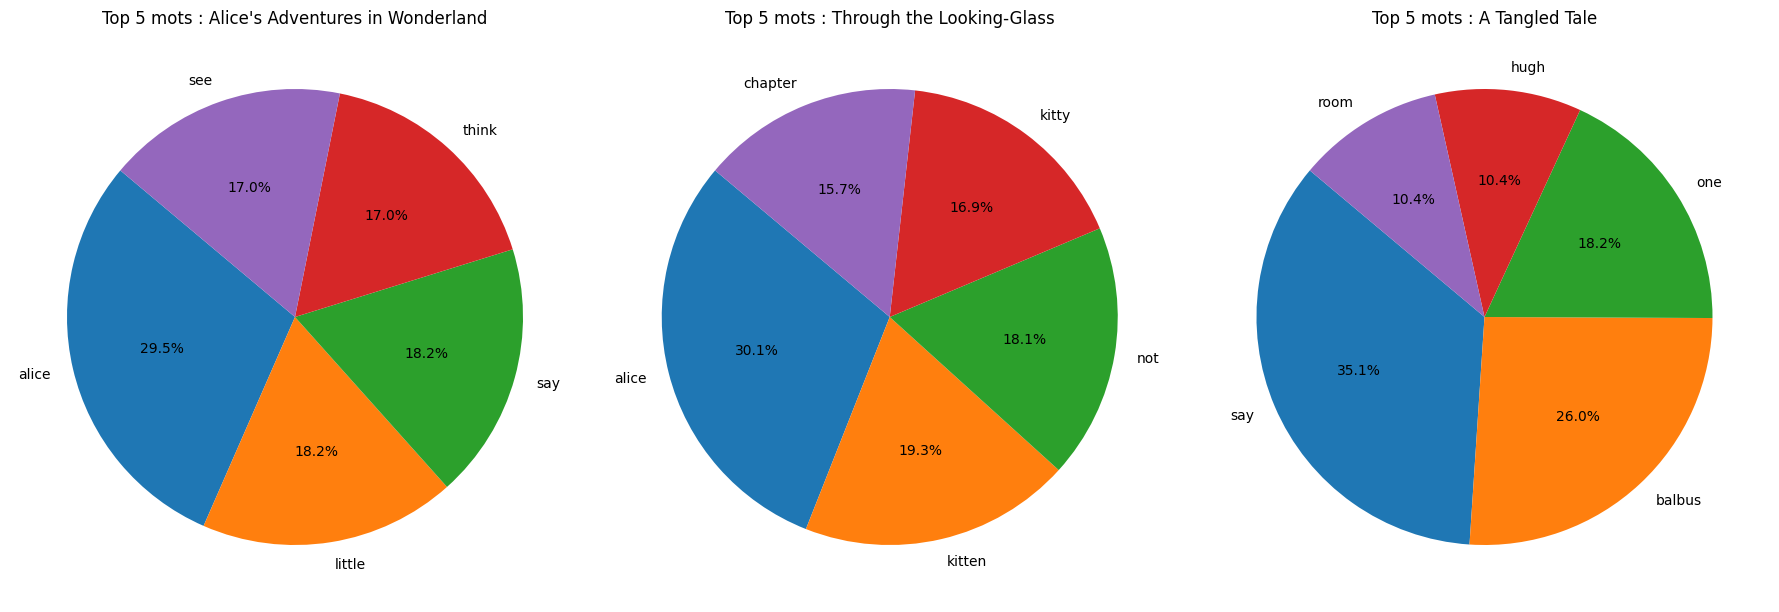

In [13]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Préparation des données (on utilise les tokens lemmatisés joints pour de meilleurs résultats)
corpus_joined = [" ".join(tokens) for tokens in book_tokens_lemmatized]

# 2. Utilisation de BoW pour trouver les mots fréquents
vectorizer = CountVectorizer(max_features=1000)
bow_matrix = vectorizer.fit_transform(corpus_joined)
words = vectorizer.get_feature_names_out()

# Affichage des 5 mots les plus fréquents par livre
plt.figure(figsize=(18, 6))

for i in range(len(titles)):
    # Calcul des fréquences pour le document i
    word_counts = bow_matrix[i].toarray().flatten()
    df_bow = pd.DataFrame({'word': words, 'count': word_counts})
    top_5 = df_bow.sort_values(by='count', ascending=False).head(5)

    # 4. Affichage du Pie Plot
    plt.subplot(1, 3, i+1)
    plt.pie(top_5['count'], labels=top_5['word'], autopct='%1.1f%%', startangle=140)
    plt.title(f"Top 5 mots : {titles[i]}")

plt.tight_layout()
plt.show()

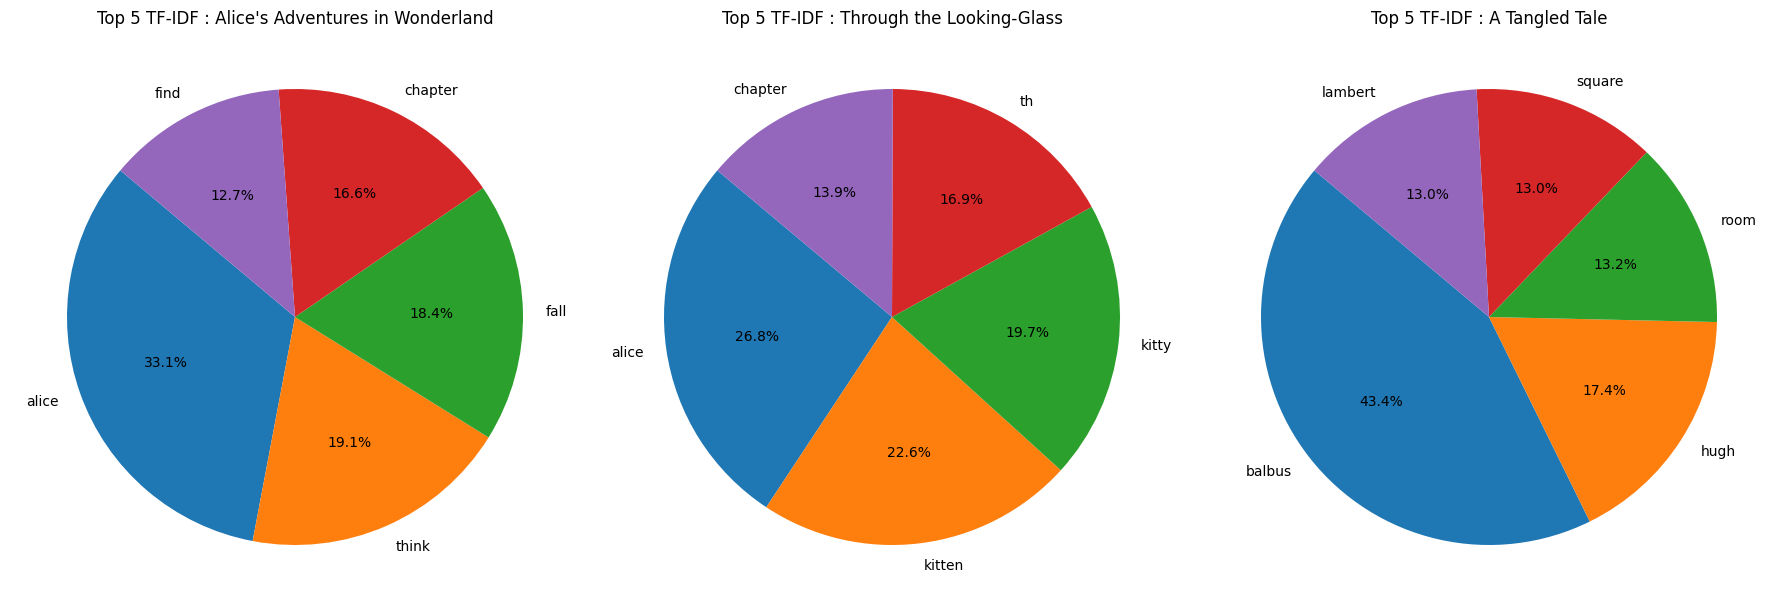

Analyse terminée : Le TF-IDF a permis d'isoler des mots plus caractéristiques de chaque histoire.


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Création du BoW avec TF-IDF
# min_df=1, max_df=2 car nous avons un petit dataset de 3 livres
tfidf_vec = TfidfVectorizer(min_df=1, max_df=2)
tfidf_matrix = tfidf_vec.fit_transform(corpus_joined)
words_tfidf = tfidf_vec.get_feature_names_out()

# 2. Affichage des Pie Plots pour TF-IDF
plt.figure(figsize=(18, 6))

for i in range(len(titles)):
    tfidf_scores = tfidf_matrix[i].toarray().flatten()
    df_tfidf = pd.DataFrame({'word': words_tfidf, 'score': tfidf_scores})
    top_5_tfidf = df_tfidf.sort_values(by='score', ascending=False).head(5)

    plt.subplot(1, 3, i+1)
    plt.pie(top_5_tfidf['score'], labels=top_5_tfidf['word'], autopct='%1.1f%%', startangle=140)
    plt.title(f"Top 5 TF-IDF : {titles[i]}")

plt.tight_layout()
plt.show()

print("Analyse terminée : Le TF-IDF a permis d'isoler des mots plus caractéristiques de chaque histoire.")

In [15]:
import pandas as pd

comparison_data = []

for i, title in enumerate(titles):
    # Extraction du Top 5 BoW
    counts = bow_matrix[i].toarray().flatten()
    df_b = pd.DataFrame({'word': words, 'count': counts})
    top_bow = df_b.sort_values(by='count', ascending=False).head(5)['word'].tolist()

    # Extraction du Top 5 TF-IDF
    scores = tfidf_matrix[i].toarray().flatten()
    df_t = pd.DataFrame({'word': words_tfidf, 'score': scores})
    top_tfidf = df_t.sort_values(by='score', ascending=False).head(5)['word'].tolist()

    comparison_data.append({
        'Livre': title,
        'Top 5 BoW (Fréquence brute)': ", ".join(top_bow),
        'Top 5 TF-IDF (Pertinence)': ", ".join(top_tfidf)
    })

# Création et affichage du tableau récapitulatif
df_comparison = pd.DataFrame(comparison_data)
display(df_comparison)

,Livre,Top 5 BoW (Fréquence brute),Top 5 TF-IDF (Pertinence)
0,Alice's Adventures in Wonderland,"alice, little, say, think, see","alice, think, fall, chapter, find"
1,Through the Looking-Glass,"alice, kitten, not, kitty, chapter","alice, kitten, kitty, th, chapter"
2,A Tangled Tale,"say, balbus, one, hugh, room","balbus, hugh, room, square, lambert"
